# SVM training descriptor analysis

Reads a trained SVM checkpoint:

- `svm_qsar12_zscores.txt` at the checkpoint root
- `summary/svm_qsar12_training_descriptors.csv`
- `summary/svm_qsar12_training_scores.csv`

Plots standardized training descriptor distributions, then sigma versus each of the four GRAR740104 sequence-order descriptors.

Edit `CHECKPOINT_DIR` in the first code cell, then run all cells.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

here = Path.cwd().resolve()
REPO_ROOT = here.parent if here.name == "notebooks" else here
CHECKPOINT_DIR = REPO_ROOT / "checkpoints" / "svm_no_class_weight"
TEST_PREDICTIONS_CSV = REPO_ROOT / "data" / "sanity_test" / "predictions_latest.csv"

DESCRIPTOR_COLUMNS = (
    "netCharge",
    "FC",
    "LW",
    "DP",
    "NK",
    "AE",
    "pcMK",
    "_SolventAccessibilityD1025",
    "tau2_GRAR740104",
    "tau4_GRAR740104",
    "QSO50_GRAR740104",
    "QSO29_GRAR740104",
)
SEQUENCE_ORDER_COLUMNS = DESCRIPTOR_COLUMNS[-4:]

plt.style.use("seaborn-v0_8-whitegrid")


def read_zscores(path: Path) -> tuple[list[str], np.ndarray, np.ndarray]:
    lines = [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    if len(lines) < 3:
        raise ValueError(f"{path} must contain descriptor names, means, and standard deviations.")
    names = [name.strip() for name in lines[0].split(",") if name.strip()]
    means = np.asarray([float(value) for value in lines[1].split(",")], dtype=np.float64)
    stds = np.asarray([float(value) for value in lines[2].split(",")], dtype=np.float64)
    if len(names) != len(means) or len(names) != len(stds):
        raise ValueError("Z-score descriptor, mean, and standard deviation counts do not match.")
    return names, means, stds


def require_columns(df: pd.DataFrame, columns: tuple[str, ...], path: Path) -> None:
    missing = [name for name in columns if name not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing columns: {', '.join(missing)}")


def load_training_tables(checkpoint_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    descriptors_path = checkpoint_dir / "summary" / "svm_qsar12_training_descriptors.csv"
    scores_path = checkpoint_dir / "summary" / "svm_qsar12_training_scores.csv"
    descriptors = pd.read_csv(descriptors_path)
    scores = pd.read_csv(scores_path)
    require_columns(descriptors, ("peptide_id", "sequence", "label") + DESCRIPTOR_COLUMNS, descriptors_path)
    require_columns(scores, ("peptide_id", "sequence", "label", "prediction", "sigma", "P(AMP)"), scores_path)
    return descriptors, scores


def load_test_predictions(path: Path, names: list[str]) -> pd.DataFrame:
    if not path.is_file():
        return pd.DataFrame(columns=["id", "sigma", *names])
    frame = pd.read_csv(path)
    require_columns(frame, ("id", "sigma", *names), path)
    return frame


zscore_path = CHECKPOINT_DIR / "svm_qsar12_zscores.txt"
descriptor_names, descriptor_means, descriptor_stds = read_zscores(zscore_path)
descriptors, scores = load_training_tables(CHECKPOINT_DIR)
merged = descriptors.merge(scores[["peptide_id", "prediction", "sigma", "P(AMP)"]], on="peptide_id", how="inner")
test_predictions = load_test_predictions(TEST_PREDICTIONS_CSV, descriptor_names)

print(f"Checkpoint : {CHECKPOINT_DIR}")
print(f"Descriptors: {len(descriptors)} rows, scores: {len(scores)} rows, merged: {len(merged)} rows")
print(f"Test predictions: {len(test_predictions)} rows from {TEST_PREDICTIONS_CSV}")
print(f"Z-score file descriptors: {', '.join(descriptor_names)}")

Checkpoint : /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/checkpoints/svm_no_class_weight
Descriptors: 3329 rows, scores: 3329 rows, merged: 3329 rows
Test predictions: 31 rows from /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/sanity_test/predictions_latest.csv
Z-score file descriptors: netCharge, FC, LW, DP, NK, AE, pcMK, _SolventAccessibilityD1025, tau2_GRAR740104, tau4_GRAR740104, QSO50_GRAR740104, QSO29_GRAR740104


## Standardized descriptor distributions

Each QSAR-12 descriptor is standardized with the checkpoint training mean and standard deviation. The boxplots show the resulting training-set z-score distributions.

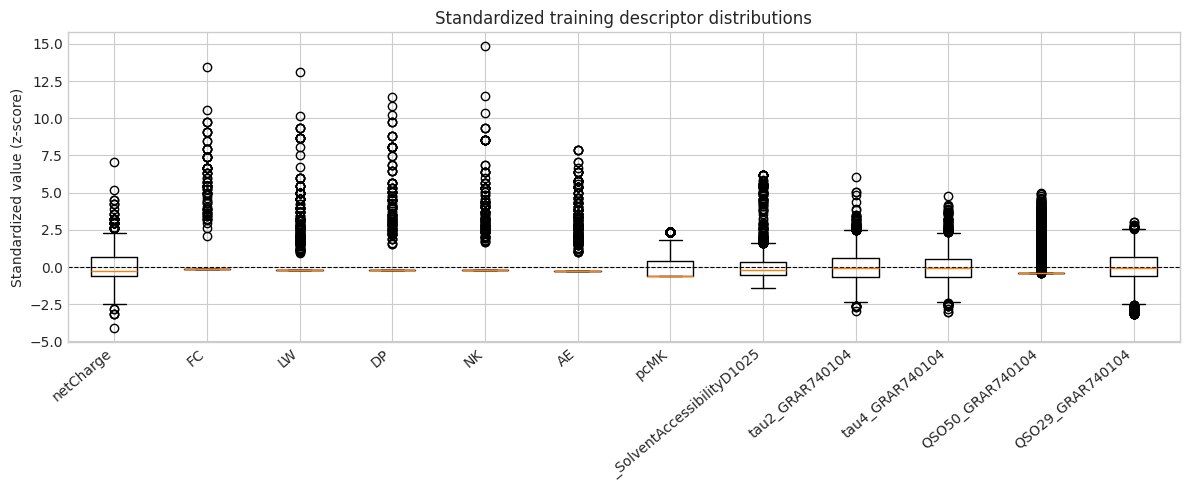

In [2]:
def standardized_descriptor_frame(
    frame: pd.DataFrame,
    names: list[str],
    means: np.ndarray,
    stds: np.ndarray,
) -> pd.DataFrame:
    safe_stds = np.where(stds > 0, stds, 1.0)
    return (frame[names] - means) / safe_stds


def plot_standardized_descriptor_scores(frame: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(
        [frame[name].dropna().to_numpy() for name in frame.columns],
        tick_labels=frame.columns,
        showfliers=True,
    )
    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticklabels(frame.columns, rotation=40, ha="right")
    ax.set_ylabel("Standardized value (z-score)")
    ax.set_title("Standardized training descriptor distributions")
    fig.tight_layout()
    plt.show()


standardized_descriptors = standardized_descriptor_frame(
    descriptors,
    descriptor_names,
    descriptor_means,
    descriptor_stds,
)
plot_standardized_descriptor_scores(standardized_descriptors)

## Sigma vs GRAR740104 descriptors

Each scatter overlays the labeled training data with test predictions from `TEST_PREDICTIONS_CSV`. Test points are blue and annotated with their IDs.

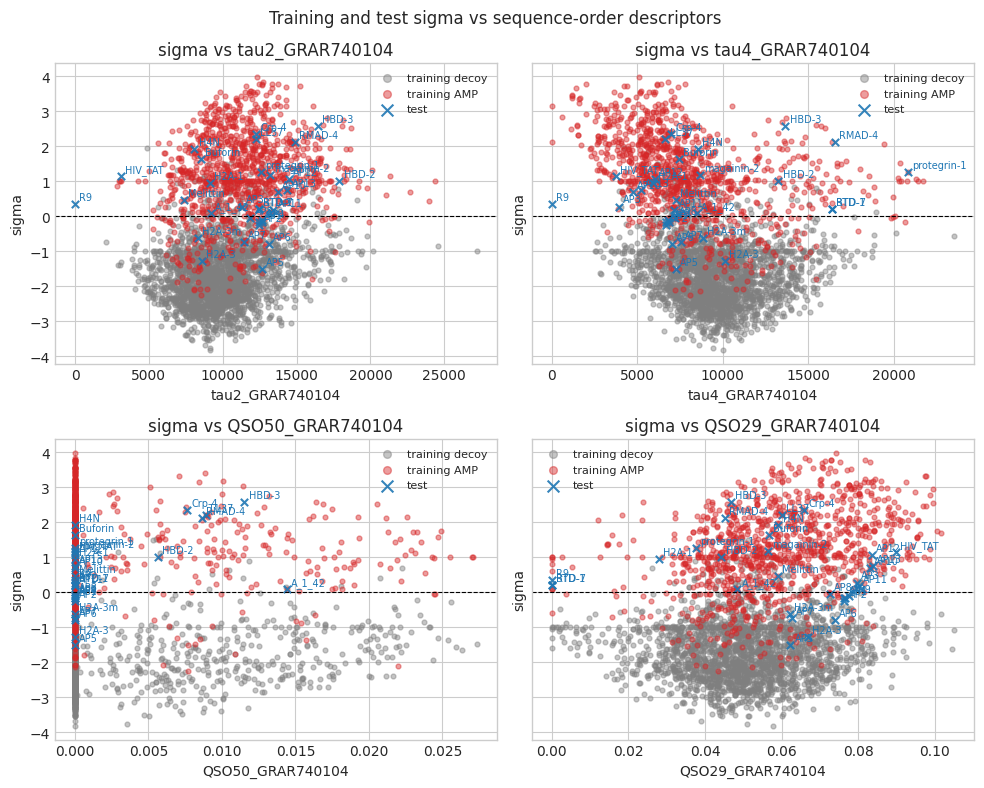

In [3]:
def annotate_test_points(ax, frame: pd.DataFrame, descriptor: str) -> None:
    for point in frame.itertuples(index=False):
        ax.annotate(
            str(point.id),
            (getattr(point, descriptor), point.sigma),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
            color="tab:blue",
        )


def scatter_sigma_vs_descriptor(
    ax,
    training: pd.DataFrame,
    test: pd.DataFrame,
    descriptor: str,
) -> None:
    amp = training[training["label"] == 1]
    decoy = training[training["label"] == -1]
    ax.scatter(decoy[descriptor], decoy["sigma"], s=12, alpha=0.45, c="tab:gray", label="training decoy")
    ax.scatter(amp[descriptor], amp["sigma"], s=12, alpha=0.45, c="tab:red", label="training AMP")
    if not test.empty:
        ax.scatter(test[descriptor], test["sigma"], s=28, alpha=0.9, c="tab:blue", marker="x", label="test")
        annotate_test_points(ax, test, descriptor)
    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(descriptor)
    ax.set_ylabel("sigma")
    ax.set_title(f"sigma vs {descriptor}")
    ax.legend(markerscale=1.6, fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
for ax, column in zip(axes.ravel(), SEQUENCE_ORDER_COLUMNS):
    scatter_sigma_vs_descriptor(ax, merged, test_predictions, column)
fig.suptitle("Training and test sigma vs sequence-order descriptors")
fig.tight_layout()
plt.show()